In [1]:
import polars as pl
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerTuple

import matplotlib.pyplot as plt
from matplotlib.pyplot import tight_layout
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from modules.design import *

import numpy as np


In [2]:
def add_std_shading(ax, df, gc_benchmarks, alpha=0.3, metric="exec"):
    for benchmark, color in gc_benchmarks.items():
        bm_df = df.filter(pl.col("benchmark") == benchmark).sort("heap_rel")
        
        x = bm_df["heap_rel"].to_numpy()
        mean = bm_df[f"{metric}_rel"].to_numpy()
        std = bm_df[f"{metric}_std"].to_numpy()
        
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=alpha)

def plot_default(env, metric, benchmarks):
    df = benchmark_df.filter((pl.col("environment") == env) & pl.col("benchmark").is_in(benchmarks.keys()))
    ax = sns.lineplot(
        data=df,
        x="heap_rel",
        y=f"{metric}_rel",
        hue="benchmark",
        hue_order=benchmarks.keys(),
        palette=benchmarks,
        linewidth=2,
    )
    
    add_std_shading(ax, df, gc_benchmarks, metric=metric)

    return ax

gc_benchmarks = {
    "tarfind": "#7fc97f",
    "mont64": "#beaed4",
    "sha256": "#fdc086",
    "md5": "#dddd99",
    "crc_32": "#386cb0"
}

all_benchmarks = {
    "mont64": "#beaed4",
    "sha256": "#fdc086",
    "md5": "#dddd99",
    "crc_32": "#386cb0",
    "ud": "#f0027f",
    "xgboost": "#bf5b17",
    "tarfind": "#7fc97f",
    "huffbench": "#fb9a99",
    "statemate": "#a6cee3",
    "matmult-int": "#e78ac3",
    "nsichneu": "#ff7f00",
    "slre": "#666666",
}

In [3]:
gc_runtime_file = "../data/runtime/gc_pressure_runtime.csv"
benchmark_df = pl.read_csv(gc_runtime_file)

if not benchmark_df.select(pl.col("correct").all()).item(0,0):
    raise ValueError("Correctness check failed")

US_TO_MS = 1 / 1_000

benchmark_df = benchmark_df.with_columns(benchmark=pl.col("benchmark").str.replace("nettle-sha256", "sha256"))

benchmark_df = (
    benchmark_df.lazy()
    .with_columns(
        load_ms=(pl.col("load_program_us") + pl.col("init_runtime_us"))* US_TO_MS,
        exec_ms=pl.col("execution_time_us") * US_TO_MS,
    )
    .group_by(["benchmark", "environment", "heap"])
    .agg(
        load=pl.col("load_ms").mean(),
        load_std = pl.col("load_ms").std(),
        exec=pl.col("exec_ms").mean(),
        exec_std = pl.col("exec_ms").std(),
    )
    .with_columns(
        max_exec=pl.col("exec").max().over(["environment", "benchmark"]),
        max_load=pl.col("load").max().over(["environment", "benchmark"]),
        min_heap=pl.col("heap").min().over(["environment", "benchmark"]),
    )
    .with_columns(
        exec_rel=pl.col("exec") / pl.col("max_exec") * 100,
        load_rel=pl.col("load") / pl.col("max_load") * 100,
        heap_rel=pl.col("heap") / pl.col("min_heap") * 100,
    )
    .collect()
)

benchmark_df.filter((pl.col("environment") == "micropython")).with_columns(tmp=pl.col("heap_rel").max().over(["environment", "benchmark"])).unique("benchmark")


benchmark,environment,heap,load,load_std,exec,exec_std,max_exec,max_load,min_heap,exec_rel,load_rel,heap_rel,tmp
str,str,i64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64
"""statemate""","""micropython""",66073,754.4435,0.000535,319.33375,0.000463,319.334,754.4465,42073,99.999922,99.999602,157.04371,197.449671
"""huffbench""","""micropython""",30050,170.5925,0.000535,592.4065,0.000535,592.407,170.592625,17050,99.999916,99.999927,176.246334,199.706745
"""sha256""","""micropython""",51290,426.683875,0.000641,3118.560125,0.004643,3343.408,426.685625,30290,93.27489,99.99959,169.329812,199.042588
"""matmult-int""","""micropython""",35882,169.292,0.0,367.79125,0.000463,367.7915,169.293,21882,99.999932,99.999409,163.979527,195.96929
"""xgboost""","""micropython""",93320,1767.453125,0.000354,641.1265,0.000535,641.12675,1767.457375,60320,99.999961,99.99976,154.708223,199.469496
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""nsichneu""","""micropython""",156000,2459.265625,0.000518,170.2055,0.000535,176.652,2459.269125,126000,96.350735,99.999858,123.809524,142.857143
"""crc_32""","""micropython""",27266,95.59475,0.000463,917.8895,0.001927,1086.263,95.59475,14266,84.499748,100.0,191.125754,191.125754
"""md5""","""micropython""",13297,122.670125,0.000354,681.644625,0.059426,705.642,122.672375,12297,96.599214,99.998166,108.132065,189.452712


Some benchmarks don't have 200% relative heap size. This comes down to the fact that I reduced the heap in steps of size 1000. For small benchmarks this is quite coarse.
crc_32 for example fails at heap sizes less than 13633. The test starts at this value times two (27266) but only test 14266 (105%) and 13266 (97%) and fails.
And the largest value tested 27266 is only 191% percent of the smallest value tested (14266) => only goes to 191%

['mont64', 'sha256', 'md5', 'crc_32', 'ud', 'xgboost', 'tarfind', 'huffbench', 'statemate', 'matmult-int', 'nsichneu', 'slre']


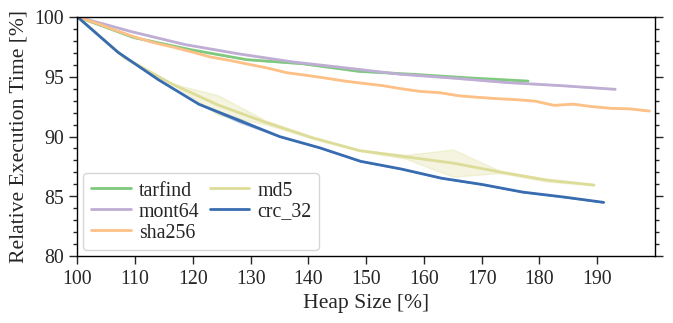

In [4]:
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig = plt.figure(figsize=(7, 3.5))

ax = plot_default("micropython", "exec", gc_benchmarks)

ax.set_ylabel("Relative Execution Time [%]")
ax.set_xlabel("Heap Size [%]")
ax.set_title("")
plt.legend(loc="lower left", ncol=2, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5, borderaxespad=0.3)

ax.set_ylim(80, 100)
ax.set_xlim(100, 200)
set_yticks(ax, 5, 1, both_sides=True)
steps = np.arange(100, 200, 10)
ax.set_xticks(steps)
ax.tick_params(axis="x", which="major", length=6, width=1)
for tick in ax.xaxis.get_major_ticks():
    tick.tick1line.set_visible(True)
ax.grid(False)
set_frame(ax, "black", 1)


plt.tight_layout()
plt.savefig("figures/gc_pressure_mp.pdf", bbox_inches="tight", format="pdf")
print(b_order)



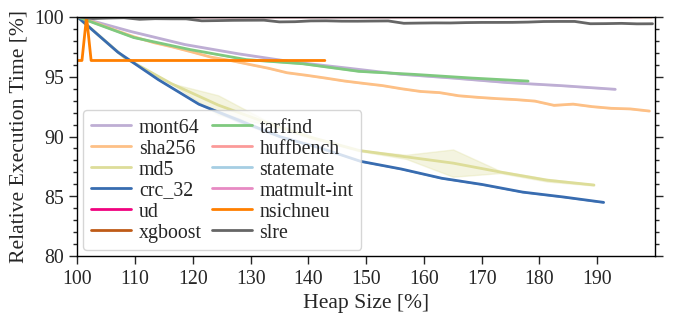

In [5]:
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig = plt.figure(figsize=(7, 3.5))

ax = plot_default("micropython", "exec", all_benchmarks)

ax.set_ylabel("Relative Execution Time [%]")
ax.set_xlabel("Heap Size [%]")
ax.set_title("")
plt.legend(loc="lower left", ncol=2, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5, borderaxespad=0.3)

ax.set_ylim(80, 100)
ax.set_xlim(100, 200)
set_yticks(ax, 5, 1, both_sides=True)
steps = np.arange(100, 200, 10)
ax.set_xticks(steps)
ax.tick_params(axis="x", which="major", length=6, width=1)
for tick in ax.xaxis.get_major_ticks():
    tick.tick1line.set_visible(True)
ax.grid(False)
set_frame(ax, "black", 1)


plt.tight_layout()
plt.savefig("figures/gc_pressure_mp.pdf", bbox_inches="tight", format="pdf")



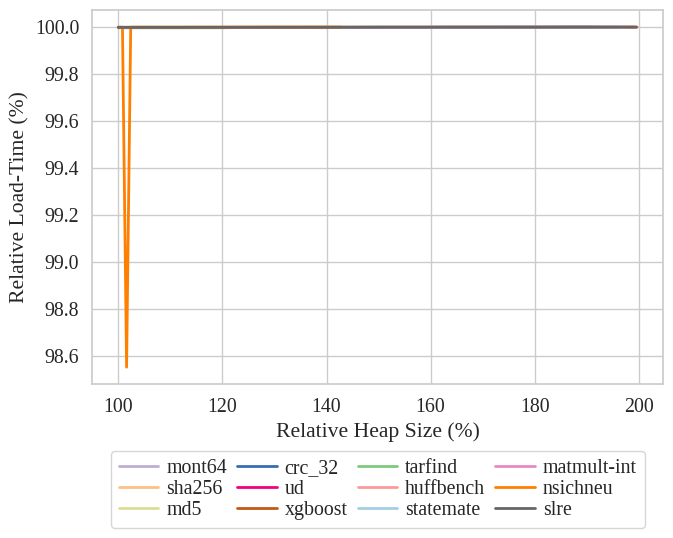

In [6]:
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig = plt.figure(figsize=(7, 6))

ax = plot_default("micropython", "load", all_benchmarks)

ax.set_ylabel("Relative Load-Time (%)")
ax.set_xlabel("Relative Heap Size (%)")
ax.set_title("")

plt.legend(loc="lower center", ncol=4, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5, borderaxespad=0.3,  bbox_to_anchor=(0.5, -0.4))

plt.tight_layout()


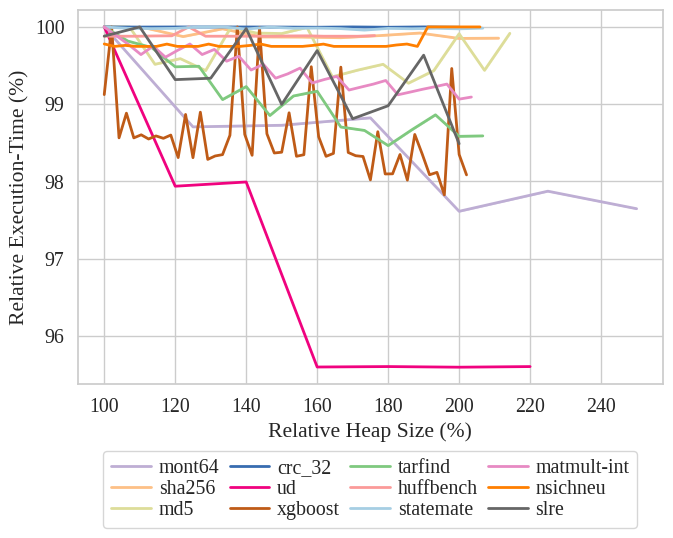

In [7]:
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig = plt.figure(figsize=(7, 6))

ax = plot_default("jerryscript", "exec", all_benchmarks)

ax.set_ylabel("Relative Execution-Time (%)")
ax.set_xlabel("Relative Heap Size (%)")
ax.set_title("")

plt.legend(loc="lower center", ncol=4, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5, borderaxespad=0.3,  bbox_to_anchor=(0.5, -0.4))

plt.tight_layout()


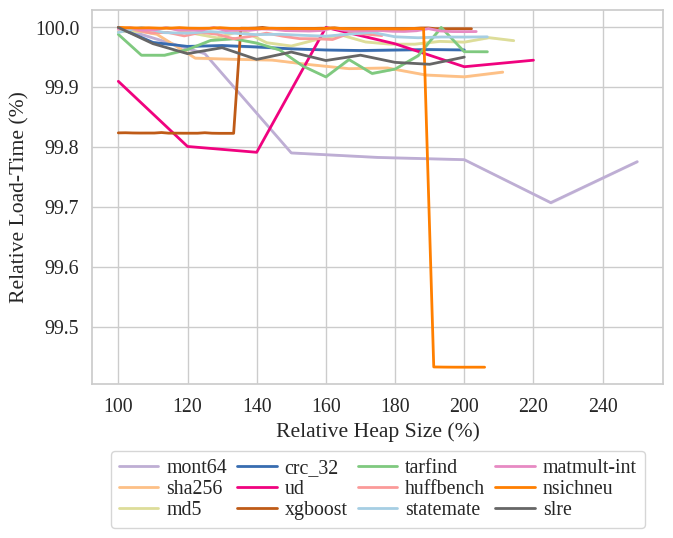

In [8]:
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig = plt.figure(figsize=(7, 6))

ax = plot_default("jerryscript", "load", all_benchmarks)

ax.set_ylabel("Relative Load-Time (%)")
ax.set_xlabel("Relative Heap Size (%)")
ax.set_title("")

plt.legend(loc="lower center", ncol=4, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5, borderaxespad=0.3,  bbox_to_anchor=(0.5, -0.4))

plt.tight_layout()

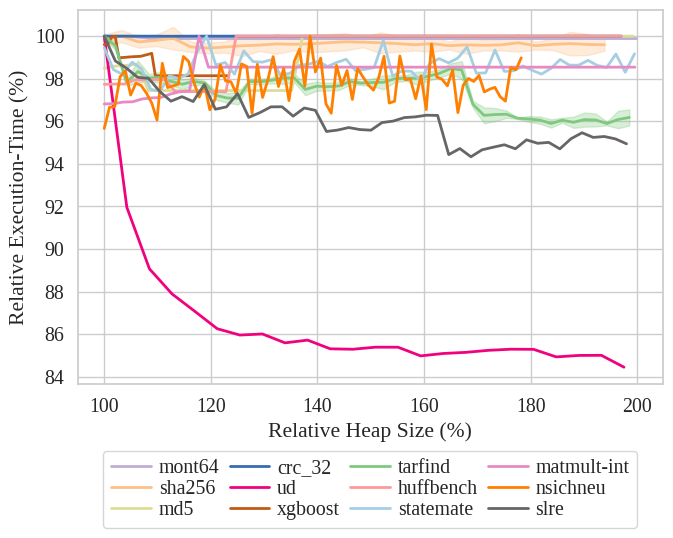

In [9]:
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig = plt.figure(figsize=(7, 6))

ax = plot_default("lua", "exec", all_benchmarks)

ax.set_ylabel("Relative Execution-Time (%)")
ax.set_xlabel("Relative Heap Size (%)")
ax.set_title("")

plt.legend(loc="lower center", ncol=4, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5, borderaxespad=0.3,  bbox_to_anchor=(0.5, -0.4))

plt.tight_layout()

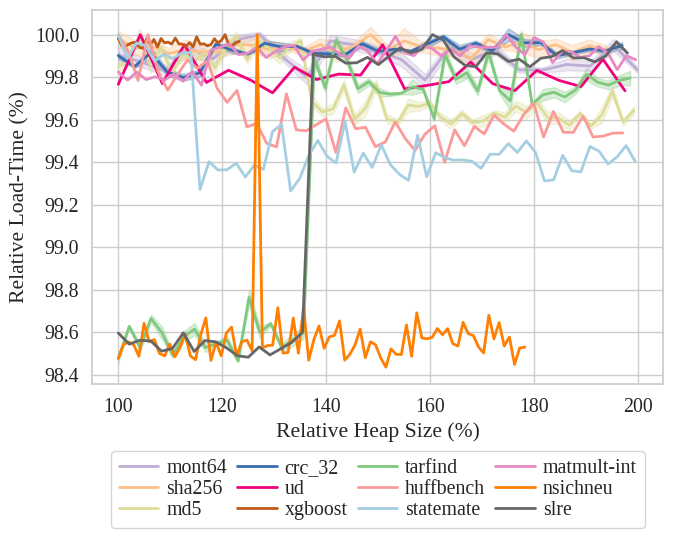

In [10]:
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig = plt.figure(figsize=(7, 6))

ax = plot_default("lua", "load", all_benchmarks)

ax.set_ylabel("Relative Load-Time (%)")
ax.set_xlabel("Relative Heap Size (%)")
ax.set_title("")

plt.legend(loc="lower center", ncol=4, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5, borderaxespad=0.3,  bbox_to_anchor=(0.5, -0.4))

plt.tight_layout()
